In [1]:
import pandas as pd
import os
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

from utils import *
import seaborn as sns
import matplotlib.colors as mcolors


In [2]:
config = yaml.safe_load(open('/Users/ursic/PhD/Projects/1_DataAnalysis_zebrafish/beads_in_zebrafish/magnetic_tweezers_SD/config.yml'))

filepath_measurements_info = config['filepath_measurements_info']
dir_plots = os.path.join(config['dir_parent'], '3_plots')  # Folder for saving plots
dir_analysis = os.path.join(config['dir_parent'], '2_analysis')  # Folder for saving analysis results
recalculate = config['recalculate']  # Whether to recalculate measurements if they already exist
pix_size = config['pix_size'] 
dt = config['dt']  # Time step in seconds

force_ranges = config['force_ranges']  # Force ranges for averaging curves

subtract_backgroung = config['subtract_background']  # Whether to subtract background from displacement

creep_only = False
if config['fit_type'] == 'creep jeff':
    creep_only = True  # If the fit type is 'creep jeff', we only plot creep curves
    
creep_only_label = '_only_creep' if creep_only else ''

displacement_column = 'CORRECTED DISPLACEMENT [um]' if subtract_backgroung else 'DISPLACEMENT [um]'  # Use the original displacement, not corrected
subtr_bck_label = 'subtr_bck' if subtract_backgroung else 'no_subtr_bck'

In [3]:
# Get the first two colors from the default Seaborn color palette
base_colors = sns.color_palette("tab10", 2)  # Blue and Orange

# Create the darker versions
darker_colors = sns.color_palette("dark", 2)  # Blue and Orange

# Combine into a single palette
custom_palette = [base_colors[0], darker_colors[0], base_colors[1], darker_colors[1]]

In [4]:
custom_dict = {'y': 0, 'taxol': 1, 'n': 2, 'noco': 3} 
pairs = [('y', 'taxol'), ('n', 'noco'), ('taxol', 'noco'), ('y', 'n')]
t_on, t_off = 10, 30

df_data_control_all = pd.read_csv(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/results_material_properties_{subtr_bck_label}.csv')
df_data_perturb_all = pd.read_csv(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_nocodazole/3_plots/results/results_material_properties_{subtr_bck_label}.csv')

# df_data_all_filtered = pd.concat([filter_data_params(df_data_control_all), filter_data_params(df_data_perturb_all)]).sort_values(by='MT_STATUS', key=lambda x: x.map(custom_dict))
df_data_all_filtered = pd.concat([df_data_control_all, df_data_perturb_all]).sort_values(by='MT_STATUS', key=lambda x: x.map(custom_dict))

df_data_control_avg_curves = pd.read_csv(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/results_parameters_curve_averaged_force_range20-60pN_{subtr_bck_label}.csv')
df_data_perturb_avg_curves = pd.read_csv(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_nocodazole/3_plots/results/results_parameters_curve_averaged_force_range20-60pN_{subtr_bck_label}.csv')

df_data_avg_curves = pd.concat([df_data_control_avg_curves, df_data_perturb_avg_curves]).sort_values(by='MT_STATUS', key=lambda x: x.map(custom_dict))

df_stats_control = pd.read_csv(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/results_material_properies_avg_curves_stats_{subtr_bck_label}.csv')
df_stats_perturbed = pd.read_csv(f'/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_nocodazole/3_plots/results/results_material_properies_avg_curves_stats_{subtr_bck_label}.csv')

df_stats = pd.concat([df_stats_control, df_stats_perturbed]).sort_values(by='MT_STATUS', key=lambda x: x.map(custom_dict))


In [5]:
df_data_avg_curves.head()

,EMBRYO,MT_STATUS,AVG_FORCE,MAGNET_STATUS,COUNT,k,eta_1,eta_2,k_err,eta_1_err,eta_2_err,t_1,R_SQUARED,rising_dif,relaxing_dif,rising_dif_norm,relative_dif,tau_r,a,elastic_viscous_ratio
0,20240621s01p01,y,41.086089,NaN,120,36.026835,58.698385,186.069188,0.505990,1.265016,1.144377,4.5,0.994917,2.081050,1.090780,0.050651,0.524149,0.814648,0.518123,1.075218
3,20240614s02p02,y,44.317979,NaN,13,30.562277,64.753002,168.120738,0.833032,2.159971,1.951887,4.5,0.985146,2.364753,1.153152,0.053359,0.487642,1.059362,0.518367,1.076272
7,20240523s02p01,y,33.278895,NaN,40,21.985470,39.095172,102.553850,0.456989,1.159886,0.819250,4.5,0.990201,2.764656,1.319635,0.083075,0.477323,0.889114,0.488245,0.954059
5,20240621s02p02,y,54.740568,NaN,17,47.212337,75.943546,246.818623,1.409250,3.514817,3.278914,4.5,0.974492,2.015498,1.000813,0.036819,0.496559,0.804277,0.521742,1.090923
12,20240705s02p01,y,28.232904,NaN,26,19.713879,31.222187,72.651253,0.384146,0.955274,0.446331,4.5,0.992386,3.143626,1.404850,0.111346,0.446888,0.791883,0.435401,0.771168


In [6]:
params = ['k', 'eta_1', 'eta_2', 'elastic_viscous_ratio', 'rising_dif', 'rising_dif_norm', 'relative_dif', 'a', 'tau_r']

labels = ['$\\kappa$ (pN/$\\mathrm{\\mu m}$)', '$\\gamma_1$ (pN s/$\\mathrm{\\mu m}$)', '$\\gamma_2$ (pN s/$\\mathrm{\\mu m}$)', 'Ratio between elastic and viscous deformation', 'Displacement ($\\mathrm{\\mu m}$)', 'Displacement / Force ($\\mathrm{\\mu m}$/ pN)', 'a = Relaxation / Displacement ', 'a', '$\\tau_R$']

mapping = {'noco': 'Nocodazole', 'taxol': 'Taxol', 'y': 'Interphase', 'n': 'M-Phase'}

(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0.55026455,
       1.29100529, 1.60846561, 0.52910053]), array([1.86923077, 0.53076923, 0.6       ]))
P-value for ('y', 'taxol'): (np.float64(1.569684400360353), np.float64(0.2170036192186139), np.float64(2.9183768456966046))
(array([3.15879828, 0.17167382, 1.99141631, 1.57939914, 0.78969957,
       0.03433476, 0.20600858, 0.06866953]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('n', 'noco'): (np.float64(4.209520456735912), np.float64(0.0007597428628633037), np.float64(14.984968658063254))
(array([1.86923077, 0.53076923, 0.6       ]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('taxol', 'noco'): (np.float64(1.4482246827897782), np.float64(0.2666050521958089), np.float64(2.3520139750426257))
(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0

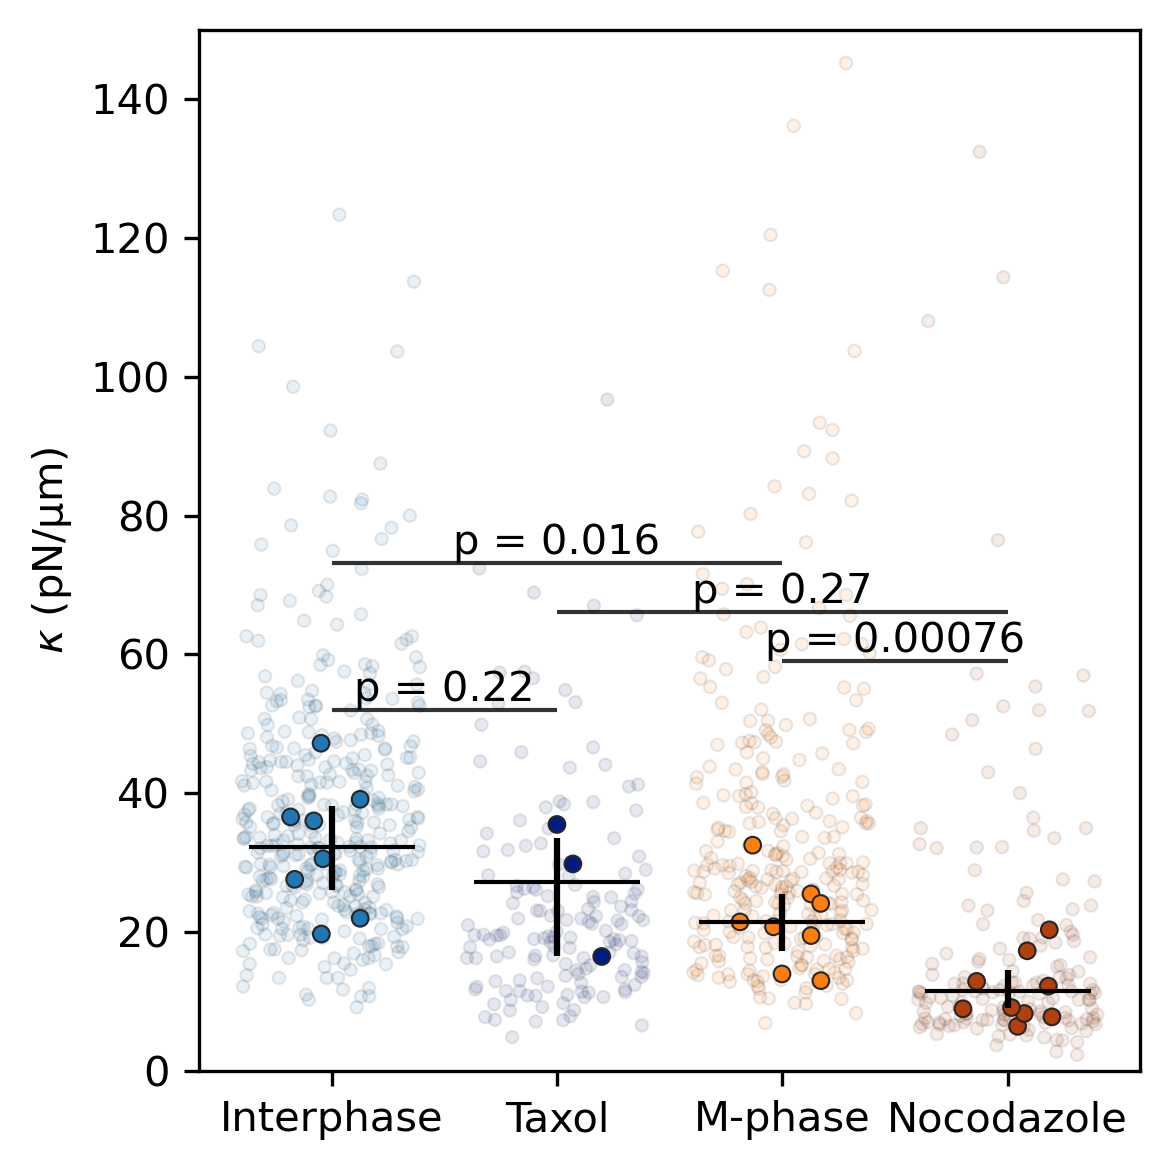

(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0.55026455,
       1.29100529, 1.60846561, 0.52910053]), array([1.86923077, 0.53076923, 0.6       ]))
P-value for ('y', 'taxol'): (np.float64(0.4379418139723394), np.float64(0.6997771746247557), np.float64(2.260252658361258))
(array([3.15879828, 0.17167382, 1.99141631, 1.57939914, 0.78969957,
       0.03433476, 0.20600858, 0.06866953]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('n', 'noco'): (np.float64(1.7440441672232843), np.float64(0.10350126354129245), np.float64(13.72019322873149))
(array([1.86923077, 0.53076923, 0.6       ]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('taxol', 'noco'): (np.float64(1.3380039848085354), np.float64(0.30798748373829793), np.float64(2.087869086420283))
(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0.5

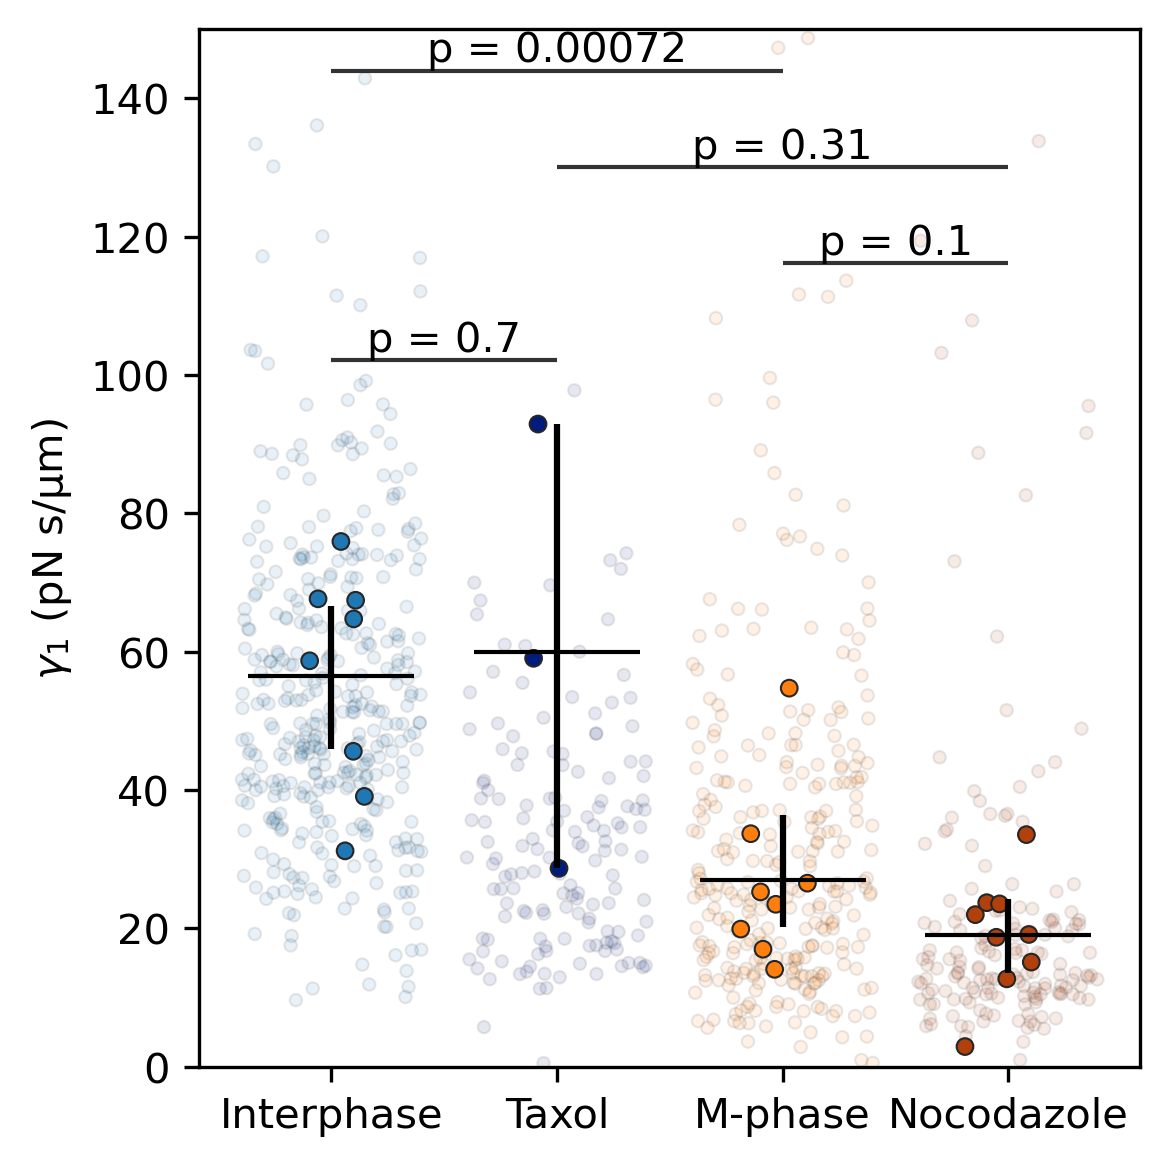

(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0.55026455,
       1.29100529, 1.60846561, 0.52910053]), array([1.86923077, 0.53076923, 0.6       ]))
P-value for ('y', 'taxol'): (np.float64(1.840098171187993), np.float64(0.12354920521097826), np.float64(5.139354610668994))
(array([3.15879828, 0.17167382, 1.99141631, 1.57939914, 0.78969957,
       0.03433476, 0.20600858, 0.06866953]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('n', 'noco'): (np.float64(1.3871439819616664), np.float64(0.18999739953990694), np.float64(12.31166910034479))
(array([1.86923077, 0.53076923, 0.6       ]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('taxol', 'noco'): (np.float64(1.585046259106579), np.float64(0.25099835799771564), np.float64(2.047452588879087))
(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0.55

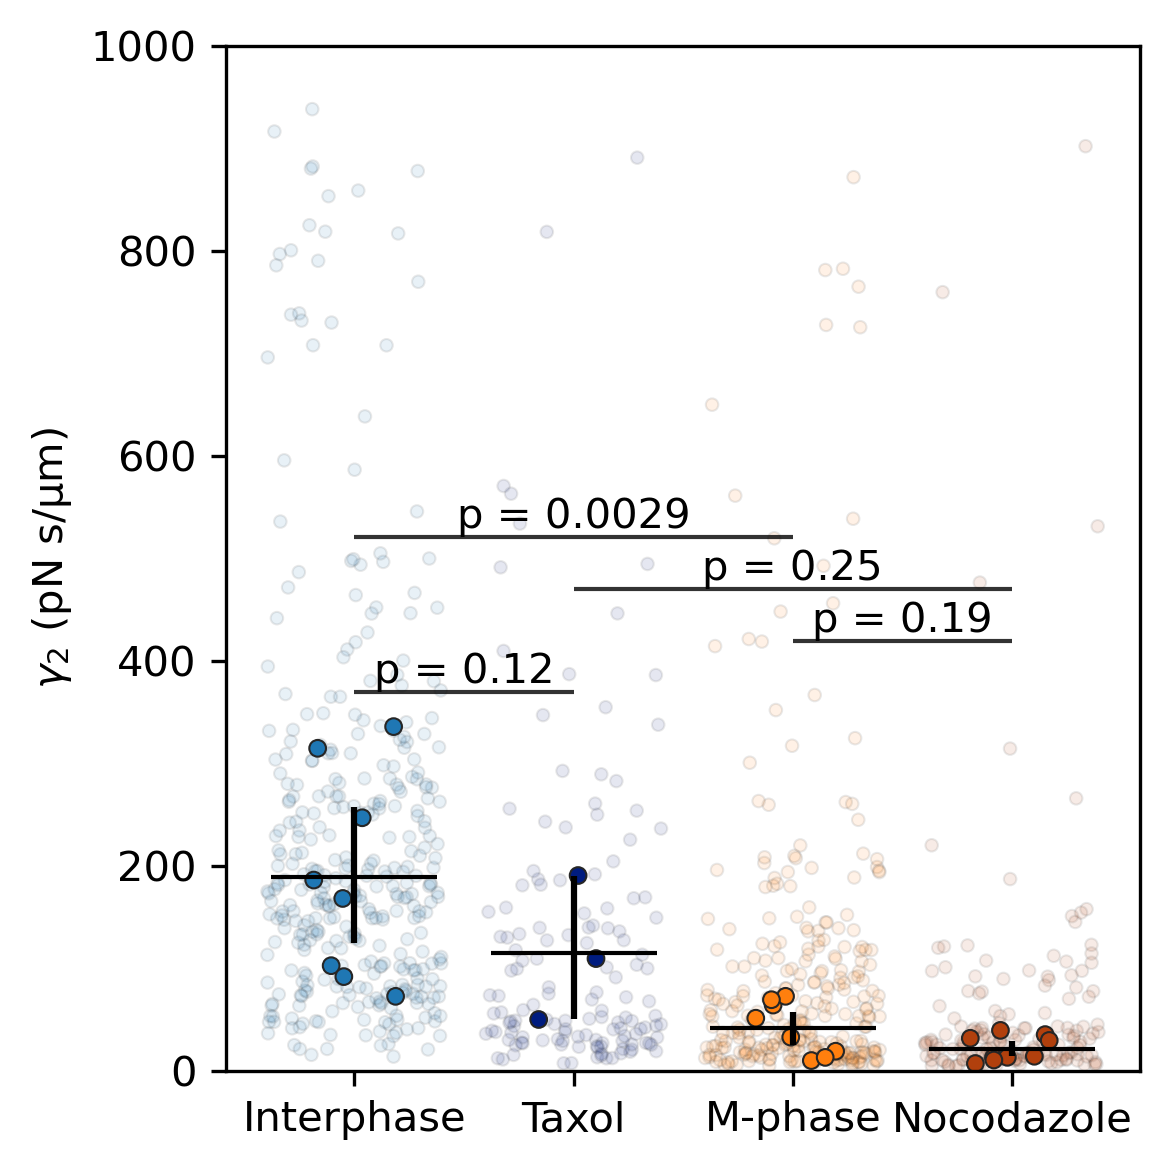

(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0.55026455,
       1.29100529, 1.60846561, 0.52910053]), array([1.86923077, 0.53076923, 0.6       ]))
P-value for ('y', 'taxol'): (np.float64(2.5772835288045703), np.float64(0.029984169321013592), np.float64(8.940091915569951))
(array([3.15879828, 0.17167382, 1.99141631, 1.57939914, 0.78969957,
       0.03433476, 0.20600858, 0.06866953]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('n', 'noco'): (np.float64(-0.7658219130563644), np.float64(0.45566505734517393), np.float64(14.999845065395052))
(array([1.86923077, 0.53076923, 0.6       ]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('taxol', 'noco'): (np.float64(3.2366299896936255), np.float64(0.03037452969740733), np.float64(4.126952229110866))
(array([2.53968254, 0.27513228, 0.84656085, 0.35978836,

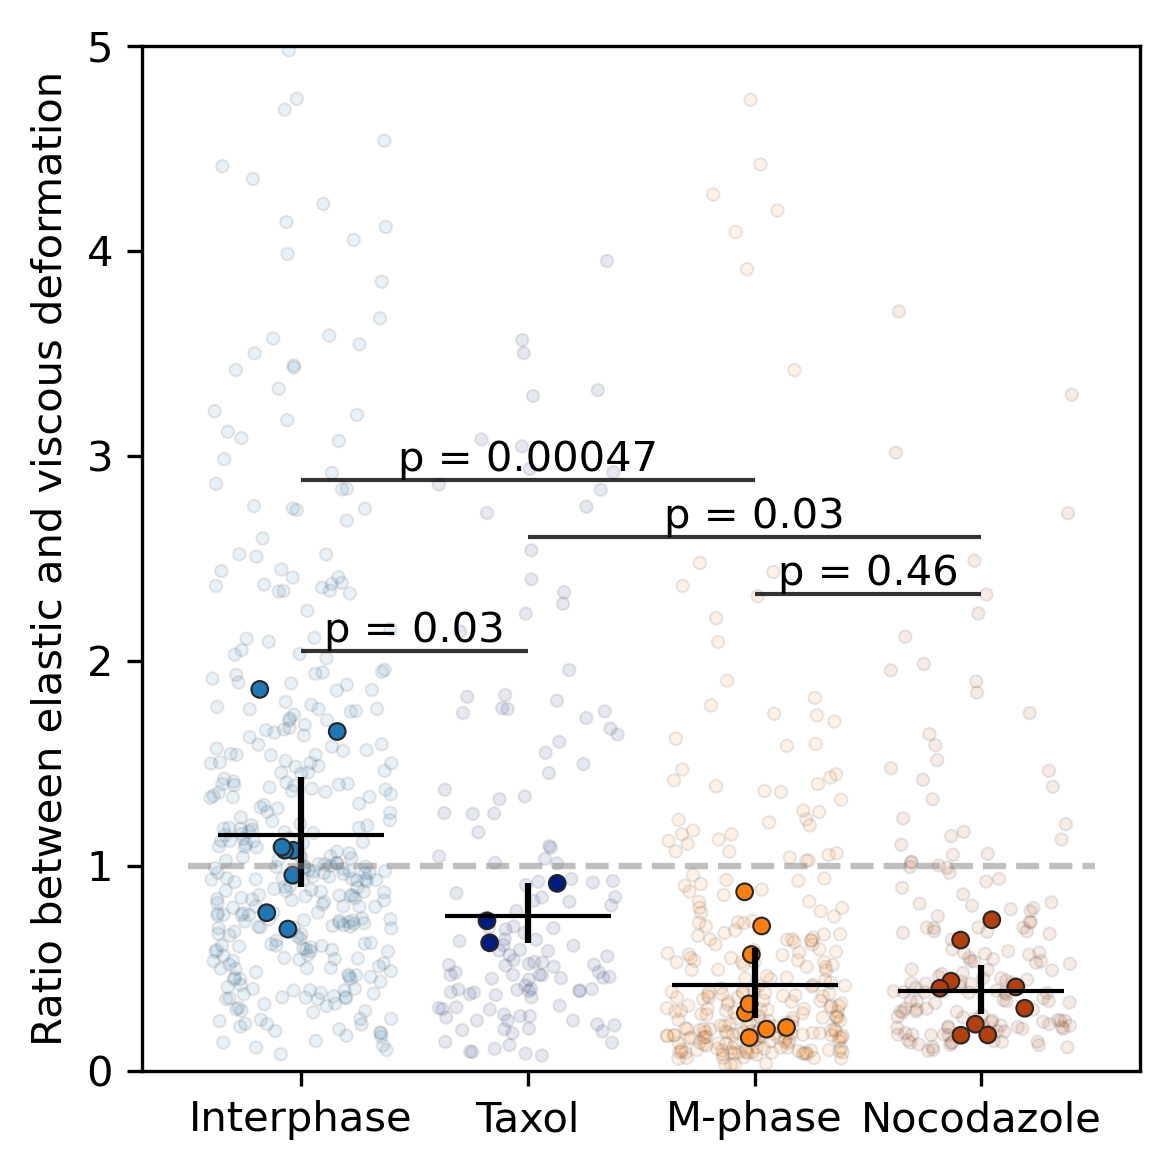

(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0.55026455,
       1.29100529, 1.60846561, 0.52910053]), array([1.86923077, 0.53076923, 0.6       ]))
P-value for ('y', 'taxol'): (np.float64(-0.6370594102374176), np.float64(0.5773525785004483), np.float64(2.510665479608576))
(array([3.15879828, 0.17167382, 1.99141631, 1.57939914, 0.78969957,
       0.03433476, 0.20600858, 0.06866953]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('n', 'noco'): (np.float64(-0.4912243701800217), np.float64(0.6313894764481072), np.float64(13.1087377219426))
(array([1.86923077, 0.53076923, 0.6       ]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('taxol', 'noco'): (np.float64(-3.061815992649231), np.float64(0.013863540457747599), np.float64(8.81371249194596))
(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0.5

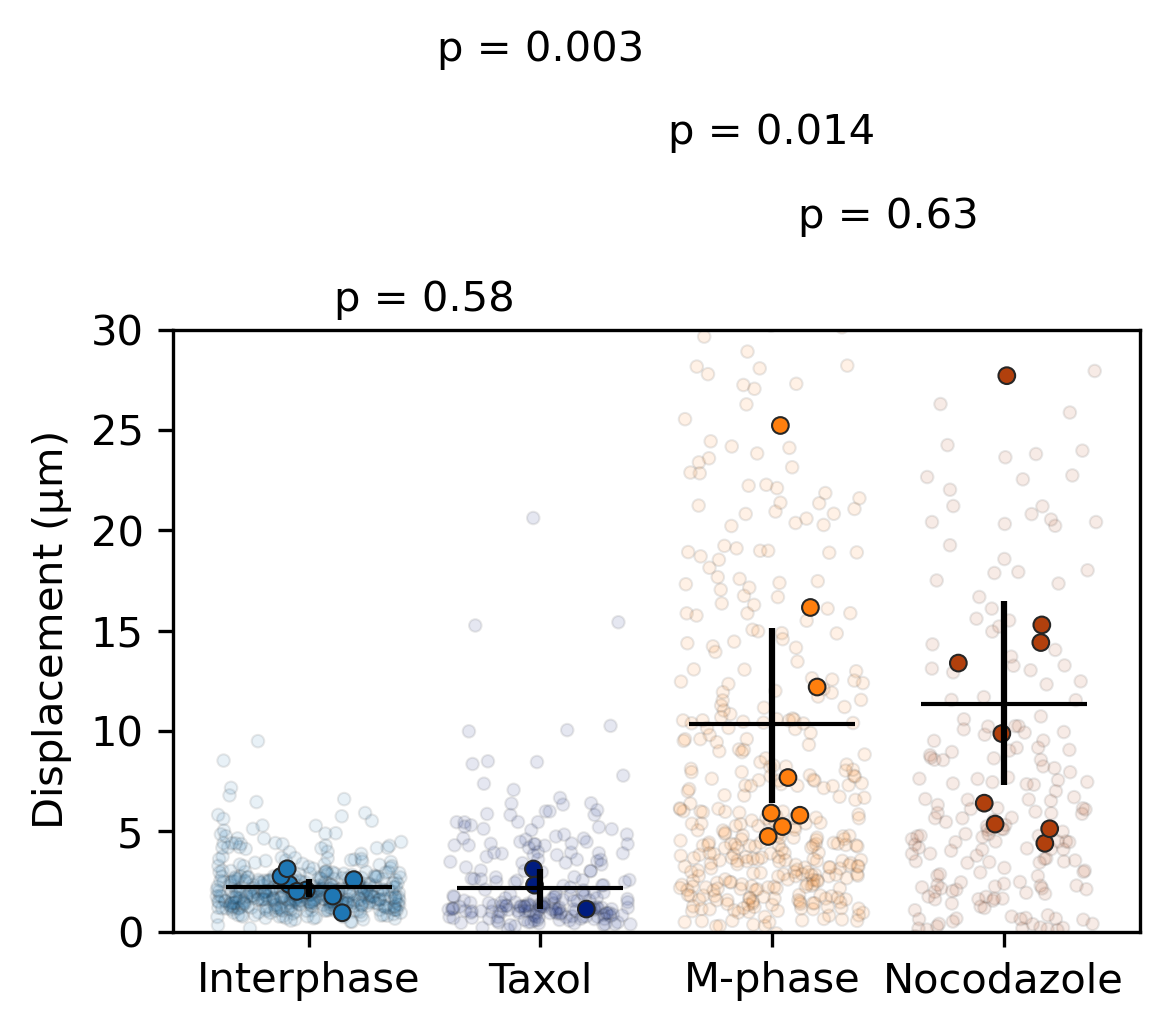

(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0.55026455,
       1.29100529, 1.60846561, 0.52910053]), array([1.86923077, 0.53076923, 0.6       ]))
P-value for ('y', 'taxol'): (np.float64(-1.6977256936789136), np.float64(0.21369224215564608), np.float64(2.329596158626242))
(array([3.15879828, 0.17167382, 1.99141631, 1.57939914, 0.78969957,
       0.03433476, 0.20600858, 0.06866953]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('n', 'noco'): (np.float64(-1.6522721916704846), np.float64(0.12567213440490801), np.float64(11.424537662070803))
(array([1.86923077, 0.53076923, 0.6       ]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('taxol', 'noco'): (np.float64(-2.840044663211557), np.float64(0.017747412311692207), np.float64(9.879469979102302))
(array([2.53968254, 0.27513228, 0.84656085, 0.35978836

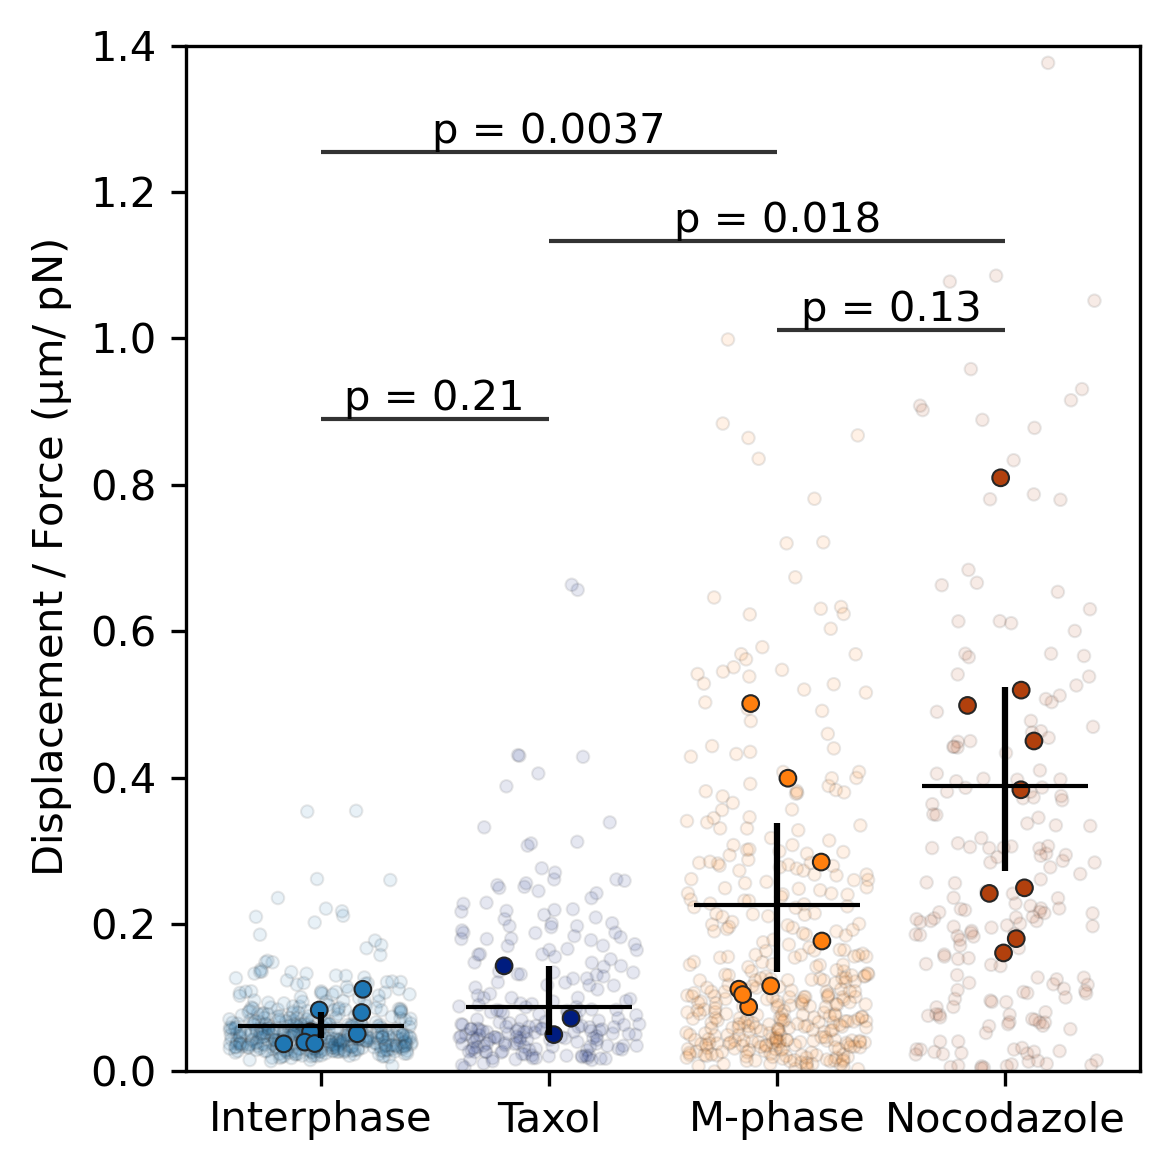

(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0.55026455,
       1.29100529, 1.60846561, 0.52910053]), array([1.86923077, 0.53076923, 0.6       ]))
P-value for ('y', 'taxol'): (np.float64(2.969768117643157), np.float64(0.01609685628827411), np.float64(8.798976581035166))
(array([3.15879828, 0.17167382, 1.99141631, 1.57939914, 0.78969957,
       0.03433476, 0.20600858, 0.06866953]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('n', 'noco'): (np.float64(-0.3883247651981323), np.float64(0.70365036555638), np.float64(13.919067143245725))
(array([1.86923077, 0.53076923, 0.6       ]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('taxol', 'noco'): (np.float64(4.512070961564492), np.float64(0.0026333250262610282), np.float64(7.130301687585191))
(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0.5

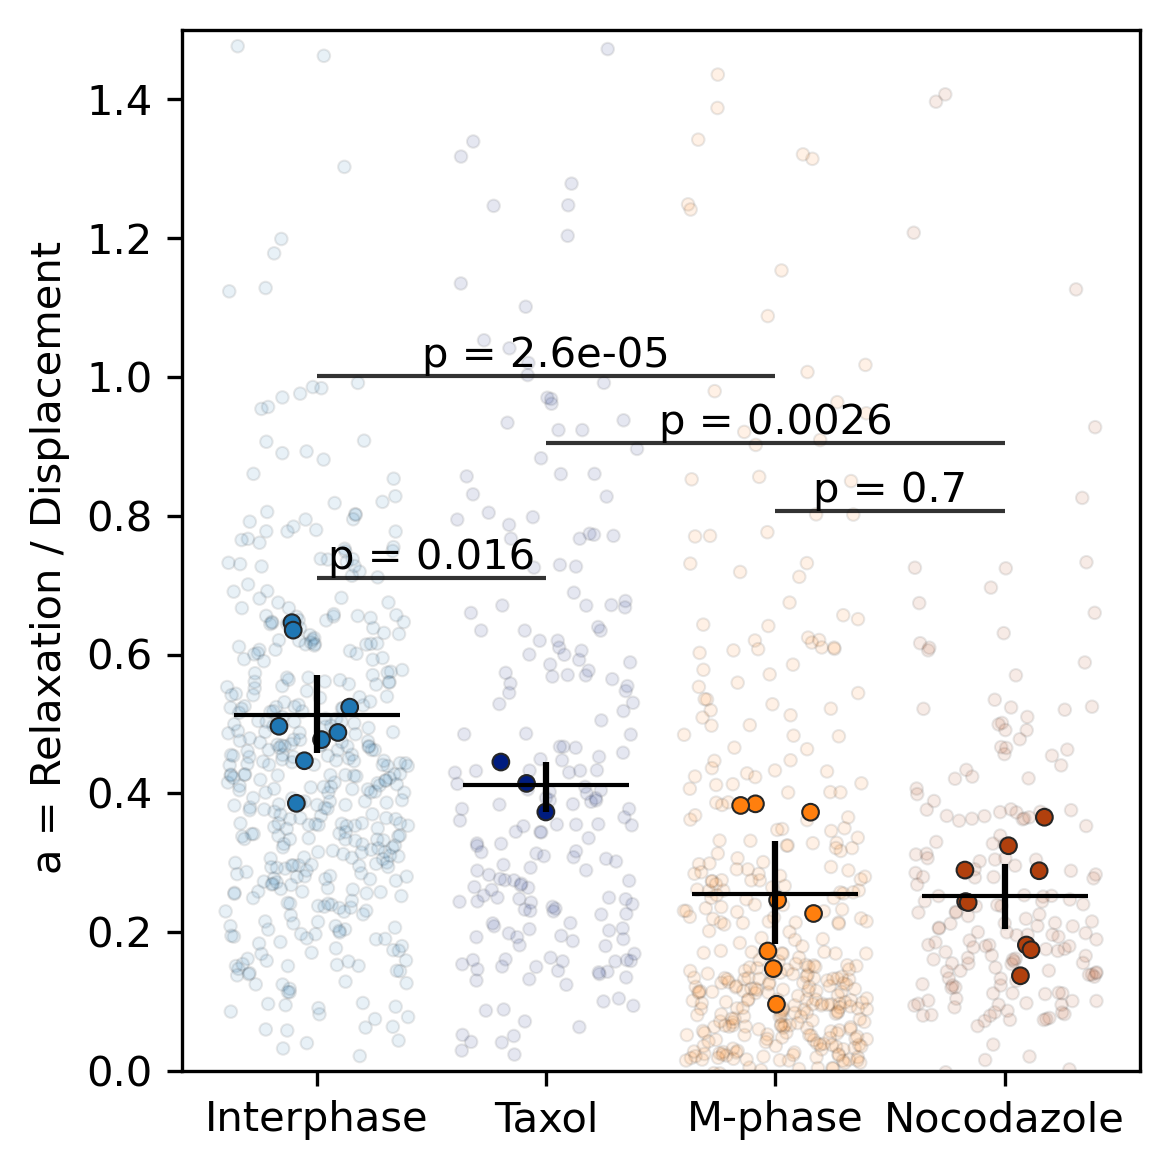

(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0.55026455,
       1.29100529, 1.60846561, 0.52910053]), array([1.86923077, 0.53076923, 0.6       ]))
P-value for ('y', 'taxol'): (np.float64(2.6556739123055584), np.float64(0.032729274650736134), np.float64(6.986491946939741))
(array([3.15879828, 0.17167382, 1.99141631, 1.57939914, 0.78969957,
       0.03433476, 0.20600858, 0.06866953]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('n', 'noco'): (np.float64(-0.7726294824244799), np.float64(0.45174589591316594), np.float64(14.99885905357236))
(array([1.86923077, 0.53076923, 0.6       ]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('taxol', 'noco'): (np.float64(3.663125648588176), np.float64(0.007915563072295226), np.float64(7.061196490537909))
(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 

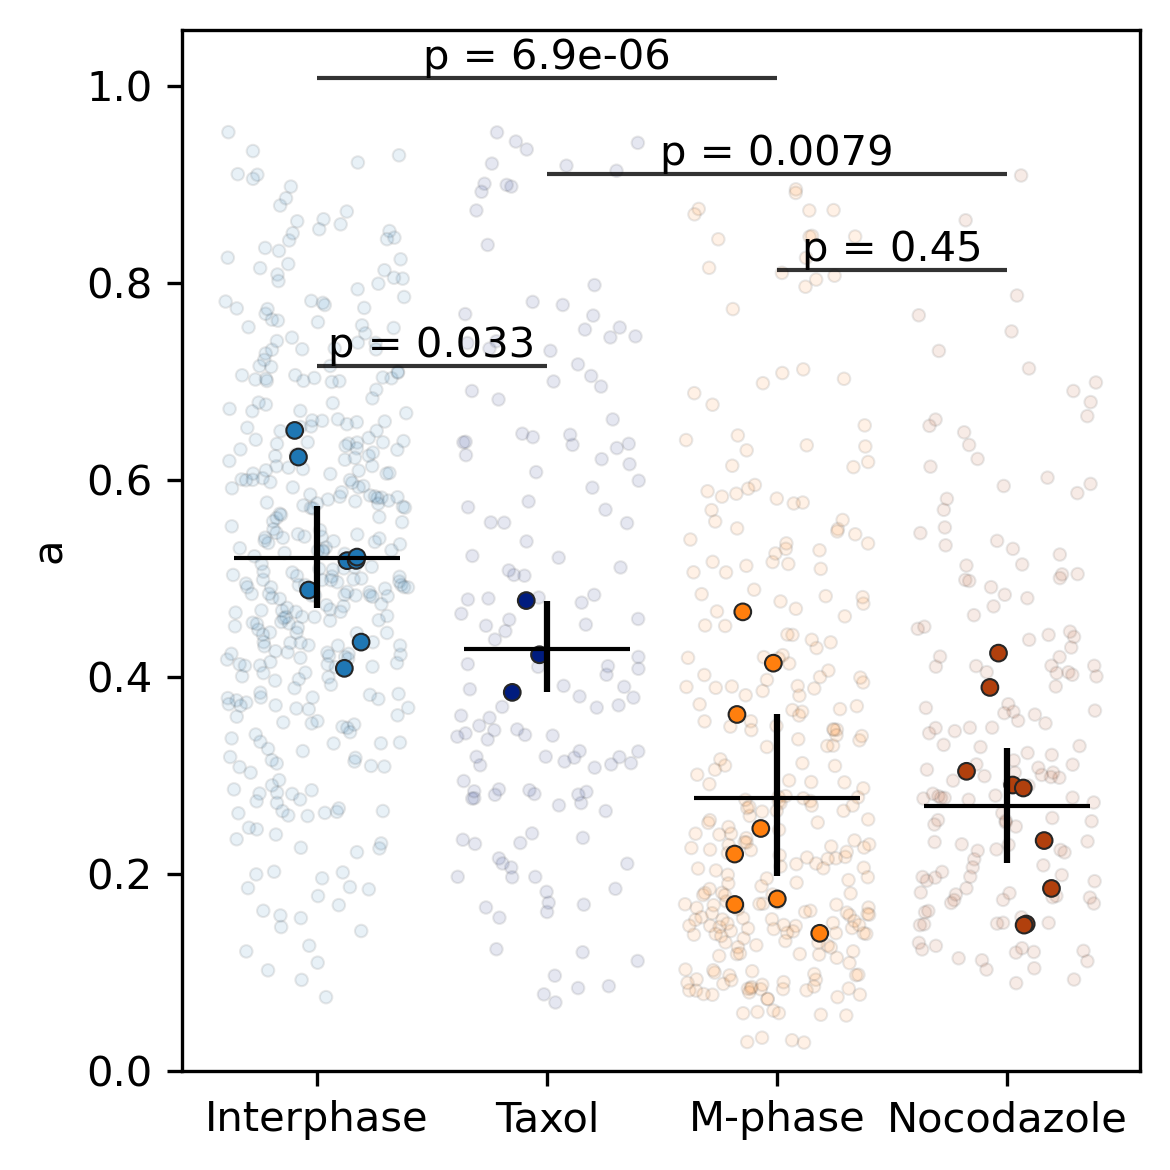

(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0.55026455,
       1.29100529, 1.60846561, 0.52910053]), array([1.86923077, 0.53076923, 0.6       ]))
P-value for ('y', 'taxol'): (np.float64(-1.0886579144901727), np.float64(0.3847291548030513), np.float64(2.114263446806447))
(array([3.15879828, 0.17167382, 1.99141631, 1.57939914, 0.78969957,
       0.03433476, 0.20600858, 0.06866953]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('n', 'noco'): (np.float64(-2.3628438984877045), np.float64(0.034565526334627346), np.float64(12.873287843587295))
(array([1.86923077, 0.53076923, 0.6       ]), array([1.41044776, 2.35074627, 0.73880597, 0.47014925, 0.40298507,
       1.81343284, 0.60447761, 0.67164179, 0.53731343]))
P-value for ('taxol', 'noco'): (np.float64(1.24281216593701), np.float64(0.2947770536456128), np.float64(3.3067271204796835))
(array([2.53968254, 0.27513228, 0.84656085, 0.35978836, 0

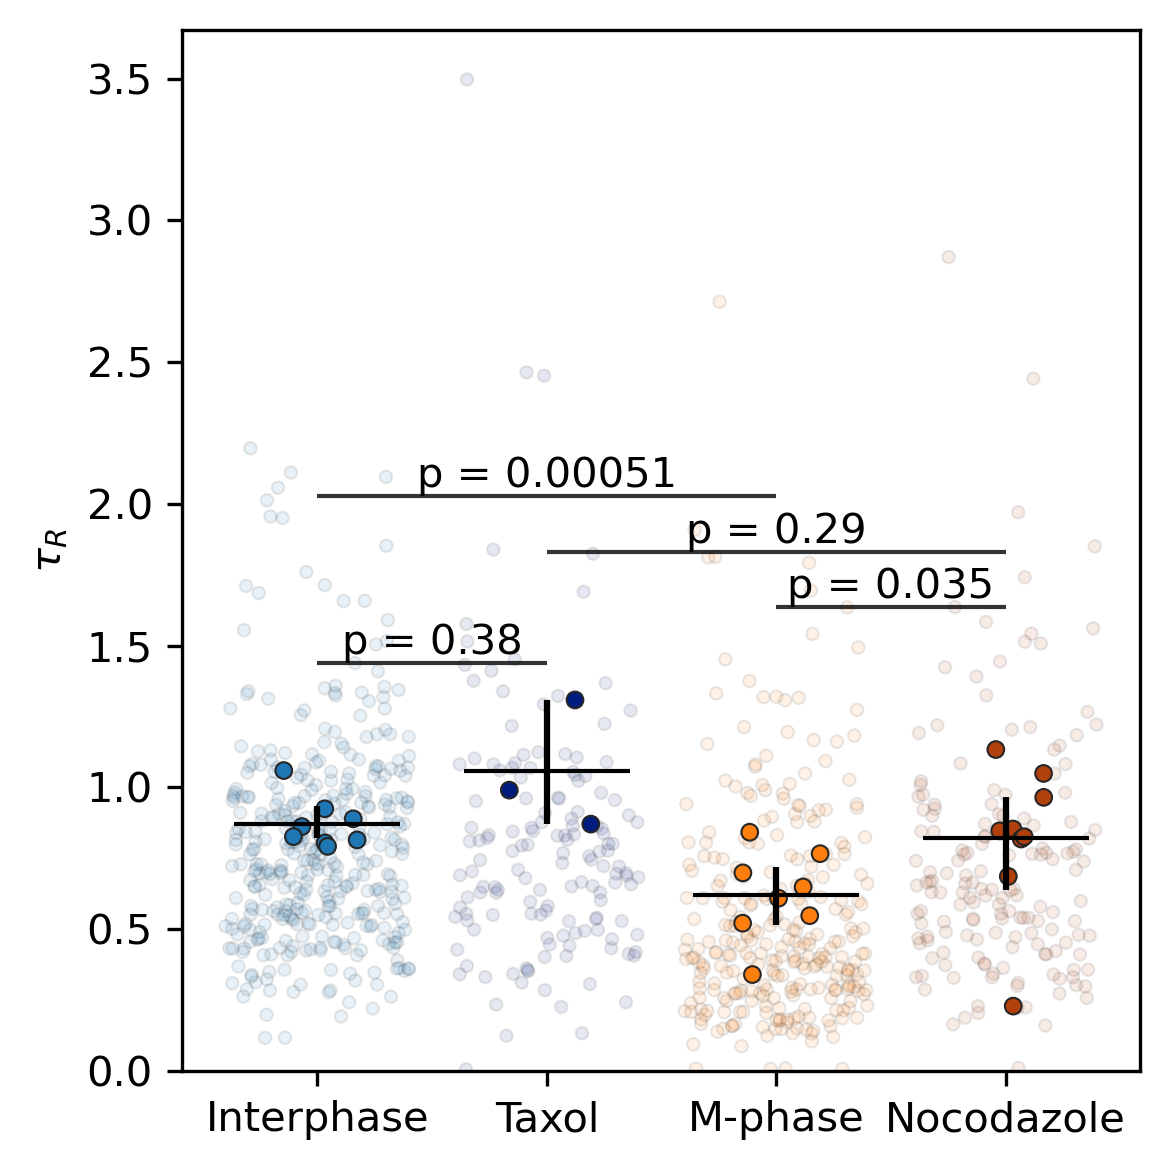

In [7]:
for (param, label) in zip(params, labels):
    df = df_data_all_filtered
    if param in ['k', 'eta_1', 'eta_2', 'elastic_viscous_ratio', 'a', 'tau_r']:
        df = filter_data_params(df_data_all_filtered)
    fig = plt.figure(figsize=(4, 4), dpi=300)
    sns.stripplot(x='MT_STATUS', y=param, hue='MT_STATUS', data=df, jitter=0.4, alpha=0.1, linewidth=0.5, legend=False, size=3, zorder=0, palette=custom_palette)
    sns.stripplot(x='MT_STATUS', y=param, hue='MT_STATUS', data=df_data_avg_curves, jitter=0.2, alpha=1, linewidth=0.5, legend=False, size=4, zorder=1, palette=custom_palette)

    plt.errorbar(df_stats.loc[df_stats['parameter']==param, 'MT_STATUS'], 
                df_stats.loc[df_stats['parameter']==param, 'weighted_average'], 
                yerr=np.array([df_stats.loc[df_stats['parameter']==param, 'y_err_low'].values, df_stats.loc[df_stats['parameter']==param, 'y_err_high'].values]), 
                marker = '_', markersize=40,  color='k', linestyle='', zorder=2)

    # plt.title(f'p = {p_value:.2g}')
    for (i, pair) in enumerate(pairs):
        weights = (df_data_avg_curves.loc[df_data_avg_curves['MT_STATUS']==pair[0], 'COUNT'].values*len(df_data_avg_curves.loc[df_data_avg_curves['MT_STATUS']==pair[0], 'COUNT'].values)/np.sum       (df_data_avg_curves.loc[df_data_avg_curves['MT_STATUS']==pair[0], 'COUNT'].values), 
        df_data_avg_curves.loc[df_data_avg_curves['MT_STATUS']==pair[1], 'COUNT'].values*len(df_data_avg_curves.loc[df_data_avg_curves['MT_STATUS']==pair[1], 'COUNT'].values)/np.sum(df_data_avg_curves.loc[df_data_avg_curves['MT_STATUS']==pair[1], 'COUNT'].values))
        # weights = (None, None)
        print(weights)
        plot_p_value(param, pair, df_data_avg_curves, weights, custom_dict, height_factor=1.1 + i*0.15)

    plt.ylabel(label)
    plt.xlabel('')
    plt.ylim(bottom=0)
    plt.xticks(ticks=['y', 'taxol', 'n', 'noco'], labels=['Interphase', 'Taxol', 'M-phase', 'Nocodazole'])
    if param == 'k':
        plt.ylim(bottom=0, top=150)
    elif param == 'eta_1':
        plt.ylim(bottom=0, top=150)
    elif param == 'eta_2':
        plt.ylim(bottom=0, top=1000)
    elif param == 'rising_dif_norm':
        plt.ylim(0, 1.4)   
    elif param == 'elastic_viscous_ratio':
        plt.ylim(bottom=0, top=5)
        plt.hlines(1, -0.5, 3.5, color='gray', linestyle='--', alpha=0.5)
    elif param == 'rising_dif':
        plt.ylim(bottom=0, top=30)
    elif param == 'relative_dif':
        plt.ylim(bottom=0, top=1.5)

    # plt.ylim(0, 1000)
    # plt.yscale('log')
    plt.tight_layout()
    plt.savefig(f'{dir_plots}/results/result_comparison_{param}_{subtr_bck_label}.svg', format='svg')
    plt.savefig(f'{dir_plots}/results/result_comparison_{param}_{subtr_bck_label}.pdf')
    plt.show()